<a href="https://colab.research.google.com/github/HazemmoAlsady/AWN_Graduation_Project/blob/main/02_batch_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cleaned Parquet
  #    ↓
# Business Analytics
  #      ↓
# KPIs + Insights + Charts

In [6]:
!pip install pyspark --quiet
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import pyspark.sql.functions as F

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import builtins
import pyspark.sql.functions as F
from pyspark.sql.functions import countDistinct

In [7]:
spark = SparkSession.builder \
    .appName("RetailAnalytics") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Cleaned Parquet

In [9]:
data = spark.read.parquet(
    "/content/drive/MyDrive/bigdata_project/"
)

print(f"Rows: {data.count():,}")

data.show(5)

Rows: 779,425
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----------+----+-----+-------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer_ID|       Country|TotalPrice|Year|Month|Quarter|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----------+----+-----+-------+
| 489460|    84568|GIRLS ALPHABET IR...|     288|2009-12-01 10:46:00| 0.21|    16167.0|United Kingdom|     60.48|2009|   12|      4|
| 489537|    20829|GLITTER HANGING B...|       6|2009-12-01 12:14:00|  2.1|    14040.0|United Kingdom|      12.6|2009|   12|      4|
| 489560|    90087|CRYSTAL SEA HORSE...|      48|2009-12-01 12:56:00| 0.85|    13526.0|United Kingdom|      40.8|2009|   12|      4|
| 489572|    22079|RIBBON REEL HEART...|       5|2009-12-01 13:29:00| 1.65|    17611.0|United Kingdom|      8.25|2009|   12|      4|
| 489573|    21625|VINTAGE UNION JAC...|       7|2009-1

# KPIs

In [10]:
kpis = data.agg(
    count("Invoice").alias("Total_Orders"),

    F.countDistinct("Invoice")
    .alias("Unique_Invoices"),

    F.countDistinct("Customer_ID")
    .alias("Unique_Customers"),

    round(sum("TotalPrice"), 2)
    .alias("Total_Revenue"),

    round(avg("TotalPrice"), 2)
    .alias("Avg_Order_Value"),

    round(sum("Quantity"), 0)
    .alias("Total_Items_Sold")
).collect()[0]

In [11]:
print("="*50)
print("KEY PERFORMANCE INDICATORS")
print("="*50)

print(f"Total Orders      : {kpis['Total_Orders']:,}")
print(f"Unique Invoices   : {kpis['Unique_Invoices']:,}")
print(f"Unique Customers  : {kpis['Unique_Customers']:,}")
print(f"Total Revenue     : £{kpis['Total_Revenue']:,.2f}")
print(f"Avg Order Value   : £{kpis['Avg_Order_Value']:,.2f}")
print(f"Total Items Sold  : {int(kpis['Total_Items_Sold']):,}")

KEY PERFORMANCE INDICATORS
Total Orders      : 779,425
Unique Invoices   : 36,969
Unique Customers  : 5,878
Total Revenue     : £17,374,804.25
Avg Order Value   : £22.29
Total Items Sold  : 10,513,952


# Product Analysis

In [12]:
top_products = data.groupBy("Description") \
    .agg(
        round(sum("TotalPrice"), 2)
        .alias("Revenue"),

        sum("Quantity")
        .alias("Units_Sold")
    ) \
    .orderBy(desc("Revenue")) \
    .limit(10)

top_products.show(truncate=False)

+----------------------------------+---------+----------+
|Description                       |Revenue  |Units_Sold|
+----------------------------------+---------+----------+
|REGENCY CAKESTAND 3 TIER          |277656.25|24124     |
|WHITE HANGING HEART T-LIGHT HOLDER|247048.01|91757     |
|PAPER CRAFT , LITTLE BIRDIE       |168469.6 |80995     |
|Manual                            |151777.67|9384      |
|JUMBO BAG RED RETROSPOT           |134307.44|74224     |
|POSTAGE                           |124648.04|5235      |
|ASSORTED COLOUR BIRD ORNAMENT     |124351.86|78234     |
|PARTY BUNTING                     |103283.38|23460     |
|MEDIUM CERAMIC TOP STORAGE JAR    |81416.73 |77916     |
|PAPER CHAIN KIT 50'S CHRISTMAS    |76598.18 |28380     |
+----------------------------------+---------+----------+



# Country Analysis

In [13]:
top_countries = data.groupBy("Country") \
    .agg(
        round(sum("TotalPrice"), 2)
        .alias("Revenue"),

        countDistinct("Customer_ID")
        .alias("Customers")
    ) \
    .orderBy(desc("Revenue"))

top_countries.show()

+---------------+------------+---------+
|        Country|     Revenue|Customers|
+---------------+------------+---------+
| United Kingdom|1.43892349E7|     5350|
|           EIRE|   616570.54|        5|
|    Netherlands|   554038.09|       22|
|        Germany|   425019.71|      107|
|         France|   348768.96|       95|
|      Australia|   169283.46|       15|
|          Spain|   108332.49|       41|
|    Switzerland|   100061.94|       22|
|         Sweden|    91515.82|       19|
|        Denmark|    68580.69|       12|
|        Belgium|    65387.82|       29|
|         Norway|     56322.5|       13|
|       Portugal|    55554.78|       24|
|Channel Islands|    44623.33|       13|
|          Japan|    43023.91|       10|
|          Italy|    32108.17|       17|
|        Finland|    29925.54|       14|
|      Singapore|    25317.06|        1|
|         Cyprus|    24849.95|       11|
|        Austria|    23613.01|       13|
+---------------+------------+---------+
only showing top

# Revenue by Country

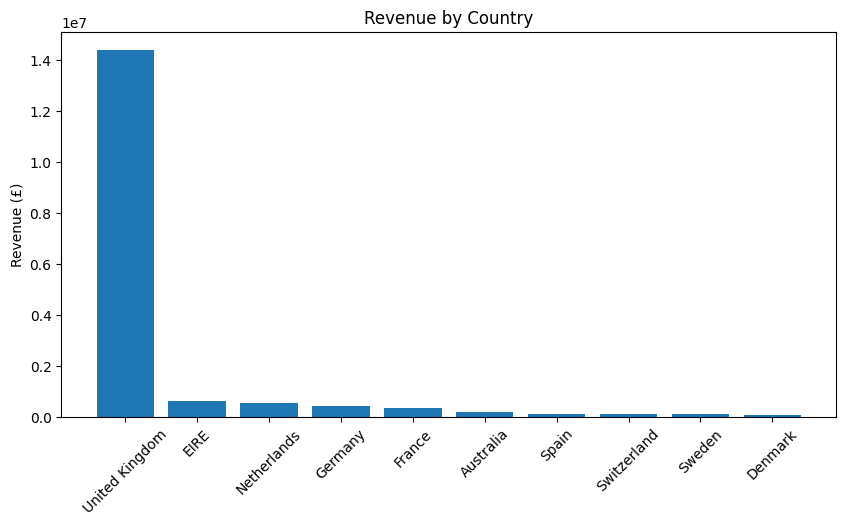

In [14]:
country_pd = top_countries.limit(10).toPandas()

plt.figure(figsize=(10,5))

plt.bar(
    country_pd["Country"],
    country_pd["Revenue"]
)

plt.xticks(rotation=45)

plt.title("Revenue by Country")

plt.ylabel("Revenue (£)")

plt.show()

#

# Top Products Chart

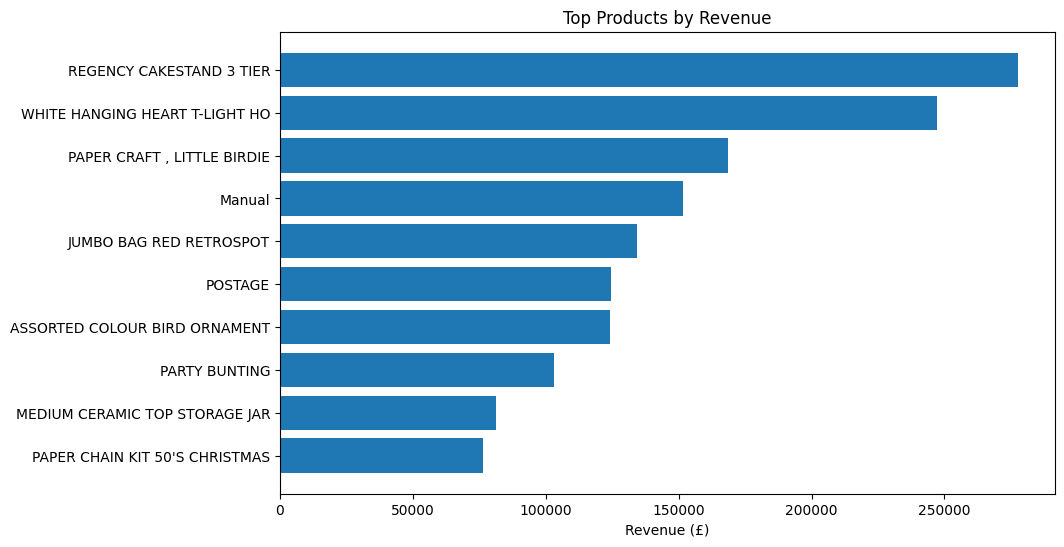

In [15]:
top_pd = top_products.toPandas()

plt.figure(figsize=(10,6))

plt.barh(
    top_pd["Description"].str[:30][::-1],
    top_pd["Revenue"][::-1]
)

plt.title("Top Products by Revenue")

plt.xlabel("Revenue (£)")

plt.show()

# Sales Trend

In [16]:
monthly_sales = data.groupBy(
    "Year",
    "Month"
).agg(
    round(sum("TotalPrice"), 2)
    .alias("Revenue")
).orderBy("Year", "Month")

In [17]:
monthly_pd = monthly_sales.toPandas()

monthly_pd["Date"] = (
    monthly_pd["Year"].astype(str)
    + "-"
    + monthly_pd["Month"].astype(str)
)

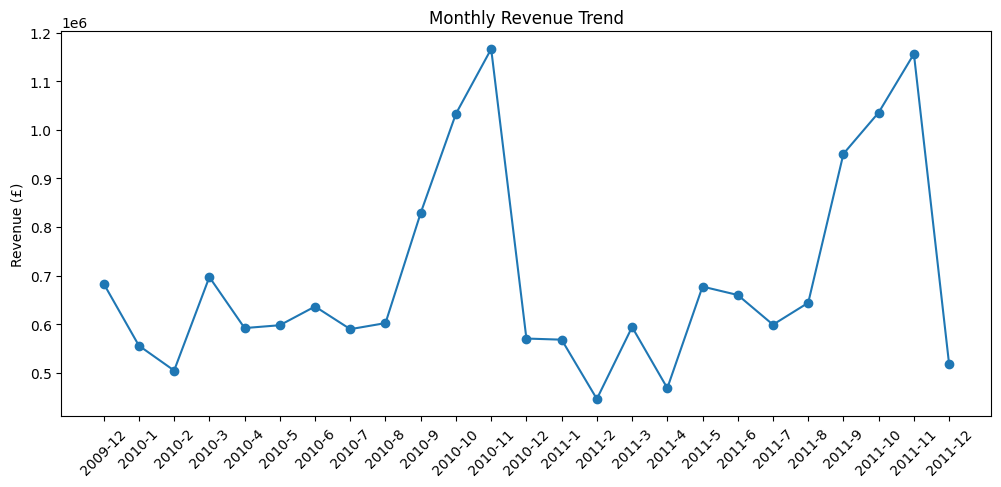

In [18]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_pd["Date"],
    monthly_pd["Revenue"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue (£)")

plt.show()

# Spark SQL

In [19]:
data.createOrReplaceTempView(
    "retail_sales"
)
spark.sql("""

SELECT
    Country,
    ROUND(SUM(TotalPrice),2) AS Revenue,
    COUNT(DISTINCT Invoice) AS Orders

FROM retail_sales

GROUP BY Country

ORDER BY Revenue DESC

LIMIT 10

""").show()

+--------------+------------+------+
|       Country|     Revenue|Orders|
+--------------+------------+------+
|United Kingdom|1.43892349E7| 33541|
|          EIRE|   616570.54|   567|
|   Netherlands|   554038.09|   228|
|       Germany|   425019.71|   789|
|        France|   348768.96|   614|
|     Australia|   169283.46|    95|
|         Spain|   108332.49|   154|
|   Switzerland|   100061.94|    90|
|        Sweden|    91515.82|   104|
|       Denmark|    68580.69|    43|
+--------------+------------+------+



# Window Functions

In [20]:
window_country = Window \
    .partitionBy("Country") \
    .orderBy(desc("Revenue"))

In [21]:
customer_rev = data.groupBy(
    "Country",
    "Customer_ID"
).agg(
    round(sum("TotalPrice"),2)
    .alias("Revenue")
)

In [22]:
customer_ranked = customer_rev \
    .withColumn(
        "Rank",
        rank().over(window_country)
    ) \
    .filter(col("Rank") <= 3)

In [23]:
customer_ranked.show()

+---------------+-----------+---------+----+
|        Country|Customer_ID|  Revenue|Rank|
+---------------+-----------+---------+----+
|      Australia|    12415.0|144458.37|   1|
|      Australia|    12431.0|  7699.79|   2|
|      Australia|    12388.0|  3901.11|   3|
|        Austria|    12360.0|  4252.89|   1|
|        Austria|    12358.0|  3887.07|   2|
|        Austria|    12865.0|  3323.47|   3|
|        Bahrain|    12355.0|   947.61|   1|
|        Bahrain|    12353.0|   406.76|   2|
|        Belgium|    12380.0|   9676.3|   1|
|        Belgium|    12417.0|  6159.05|   2|
|        Belgium|    12362.0|  5356.23|   3|
|         Brazil|    12769.0|   1143.6|   1|
|         Brazil|    12751.0|   268.27|   2|
|         Canada|    17444.0|  2940.04|   1|
|         Canada|    15390.0|  1216.66|   2|
|         Canada|    17443.0|   534.24|   3|
|Channel Islands|    14936.0| 12410.81|   1|
|Channel Islands|    14442.0|  5367.02|   2|
|Channel Islands|    14930.0|  5236.73|   3|
|         

#Correlation Analysis

In [24]:
corr_qty = data.stat.corr(
    "Quantity",
    "TotalPrice"
)

corr_price = data.stat.corr(
    "Price",
    "TotalPrice"
)

print(corr_qty)
print(corr_price)

0.8271621058441043
0.13598362405395586


In [25]:
top_products.toPandas().to_csv(
    "/content/top_products.csv",
    index=False
)

top_countries.toPandas().to_csv(
    "/content/top_countries.csv",
    index=False
)

monthly_sales.toPandas().to_csv(
    "/content/monthly_sales.csv",
    index=False
)